# 1. Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#  2. Basic overview of data

In [ ]:
df = pd.read_csv('../data/Diabetes_and_LifeStyle_Dataset_.csv')
print(df.shape)         # (97297, 31)
df.info()

(97297, 31)
<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           9729

In [3]:
print(df.shape)         # (97297, 31)
print(df.dtypes)

(97297, 31)
Age                                     int64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol       

there are strings, so convert them to something more usable (not actually transformed yet, this is just for show)

In [4]:
from IPython.display import display_html

gender_counts = df[['gender']].value_counts().to_frame()
gender_counts = df[['gender']].value_counts().reset_index()
gender_counts.columns = ["Category", "Count"]
ethnicity_counts = df[['ethnicity']].value_counts().to_frame()
ethnicity_counts = df[['ethnicity']].value_counts().reset_index()
ethnicity_counts.columns = ["Category", "Count"]
education_counts = df[['education_level']].value_counts().to_frame()
education_counts = df[['education_level']].value_counts().reset_index()
education_counts.columns = ["Category", "Count"]
income_counts = df[['income_level']].value_counts().to_frame()
income_counts = df[['income_level']].value_counts().reset_index()
income_counts.columns = ["Category", "Count"]
employment_counts = df[['employment_status']].value_counts().to_frame()
employment_counts = df[['employment_status']].value_counts().reset_index()
employment_counts.columns = ["Category", "Count"]
smoking_counts = df[['smoking_status']].value_counts().to_frame()
smoking_counts = df[['smoking_status']].value_counts().reset_index()
smoking_counts.columns = ["Category", "Count"]
diabetes_counts = df[['diabetes_stage']].value_counts().to_frame()
diabetes_counts = df[['diabetes_stage']].value_counts().reset_index()
diabetes_counts.columns = ["Category", "Count"]

combined = (

    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + gender_counts.to_html()
    + "</div>"
    +
    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + ethnicity_counts.to_html()
    + "</div>"
    
    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + education_counts.to_html()
    + "</div>"

    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + income_counts.to_html()
    + "</div>"

    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + employment_counts.to_html()
    + "</div>"

    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + smoking_counts.to_html()
    + "</div>"

    "<div style='display:inline-block; margin-right:20px; vertical-align:top;'>"
    + diabetes_counts.to_html()
    + "</div>"

)

display_html(combined, raw=True)


,Category,Count
0,Female,48873
1,Male,46460
2,Other,1964
,Category,Count
0,White,43798
1,Hispanic,19552
2,Black,17504
3,Asian,11527
4,Other,4916
,Category,Count


In [5]:
df[['diabetes_stage']].value_counts(normalize=True)

diabetes_stage
Type 2            0.597788
Pre-Diabetes      0.318746
No Diabetes       0.079519
Gestational       0.002744
Type 1            0.001203
Name: proportion, dtype: float64

# 3. Exploring data

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,97297.0,50.192699,15.492557,19.00,38.00,51.00,61.00,90.00
alcohol_consumption_per_week,97297.0,2.004543,1.418060,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,97297.0,118.942886,84.441920,0.00,57.00,100.00,160.00,833.00
diet_score,97297.0,5.995214,1.780096,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,97297.0,6.997708,1.093726,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,97297.0,5.997031,2.469805,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,97297.0,0.219657,0.414017,0.00,0.00,0.00,0.00,1.00
hypertension_history,97297.0,0.250912,0.433540,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,97297.0,0.079067,0.269845,0.00,0.00,0.00,0.00,1.00
bmi,97297.0,25.615093,3.588387,15.00,23.20,25.60,28.00,39.20


In [7]:
print(df.isnull().sum()) 
# No missing values found

Age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [8]:
print((df==0).sum())
# some values cannot be zero, such as age, BMI, blood pressure, etc. We will handle these in the preprocessing step.


Age                                       0
gender                                    0
ethnicity                                 0
education_level                           0
income_level                              0
employment_status                         0
smoking_status                            0
alcohol_consumption_per_week          13159
physical_activity_minutes_per_week       13
diet_score                               44
sleep_hours_per_day                       0
screen_time_hours_per_day                 0
family_history_diabetes               75925
hypertension_history                  72884
cardiovascular_history                89604
bmi                                       0
waist_to_hip_ratio                        0
systolic_bp                               0
diastolic_bp                              0
heart_rate                                0
cholesterol_total                         0
hdl_cholesterol                           0
ldl_cholesterol                 

In [9]:
df_smaller_than = df.copy()
df_smaller_than = df_smaller_than.drop(columns=["gender", "ethnicity", "education_level", "income_level", "employment_status", "smoking_status", "diabetes_stage"])

print((df_smaller_than<50).sum())

Age                                   45019
alcohol_consumption_per_week          97297
physical_activity_minutes_per_week    19973
diet_score                            97297
sleep_hours_per_day                   97297
screen_time_hours_per_day             97297
family_history_diabetes               97297
hypertension_history                  97297
cardiovascular_history                97297
bmi                                   97297
waist_to_hip_ratio                    97297
systolic_bp                               0
diastolic_bp                              0
heart_rate                              793
cholesterol_total                         0
hdl_cholesterol                       31924
ldl_cholesterol                           0
triglycerides                          5116
glucose_fasting                           0
glucose_postprandial                      0
insulin_level                         97297
hba1c                                 97297
diabetes_risk_score             

In [10]:
print((np.isnan(df_smaller_than)).sum())

Age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0
glucose_postprandial                  0
insulin_level                         0
hba1c                                 0
diabetes_risk_score                   0
diagnosed_diabetes                    0
dtype: int64


In [11]:
duplicates = df[df.duplicated()]
print(duplicates)
# No duplicates found

Empty DataFrame
Columns: [Age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes]
Index: []

[0 rows x 31 columns]


Text(0, 0.5, 'Count')

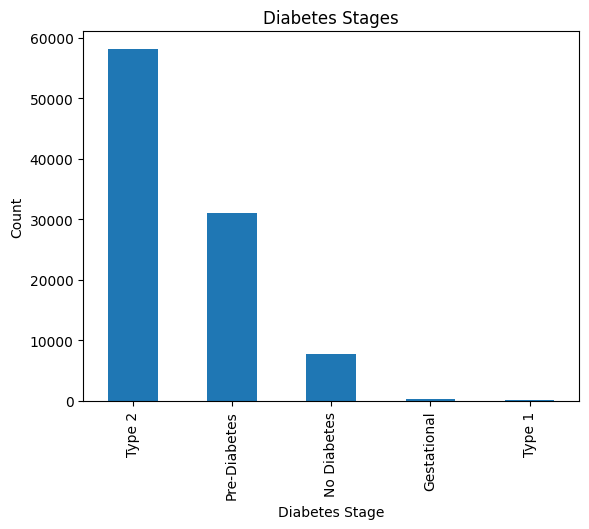

In [12]:
df['diabetes_stage'].value_counts().plot(kind='bar')
plt.title('Diabetes Stages')
plt.xlabel('Diabetes Stage')
plt.ylabel('Count')


#### box plots

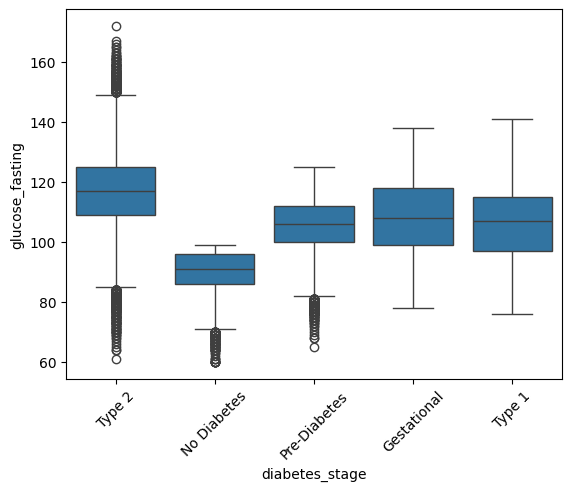

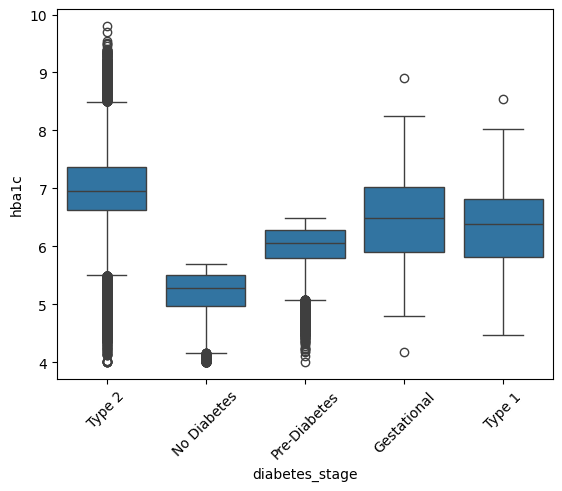

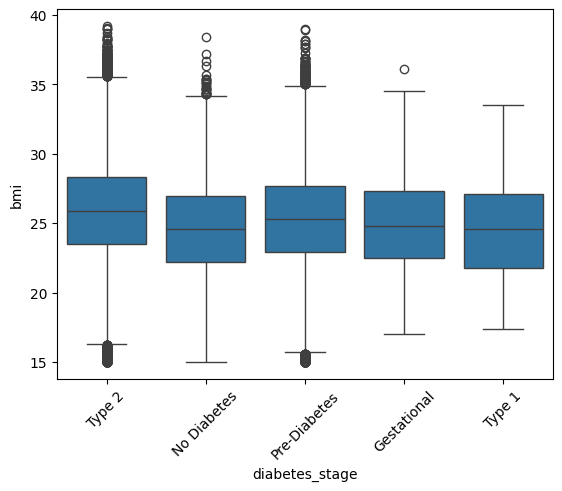

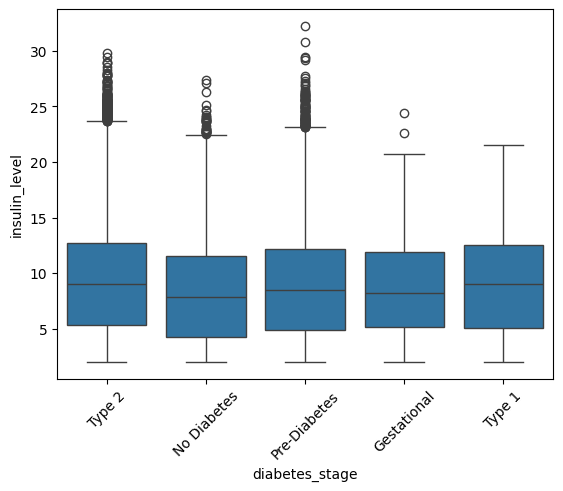

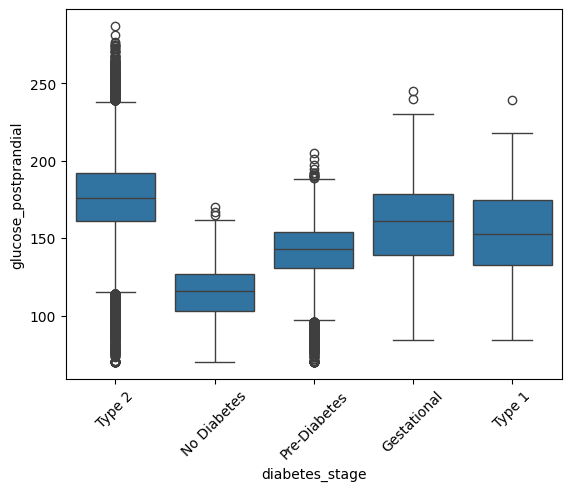

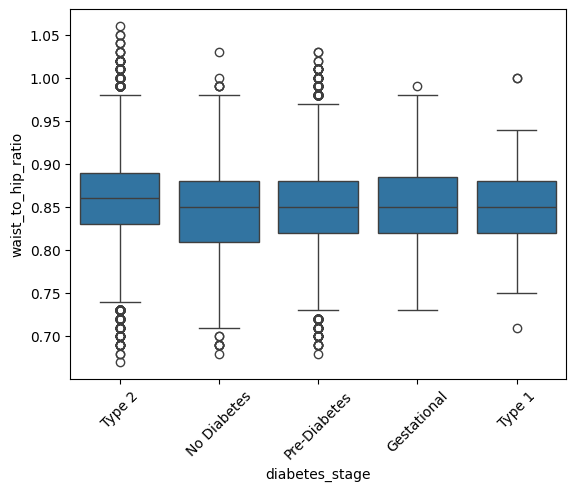

In [13]:
clinical_features = ['glucose_fasting', 'hba1c', 'bmi', 'insulin_level', 
                     'glucose_postprandial', 'waist_to_hip_ratio']

for feat in clinical_features:
    sns.boxplot(data=df, x='diabetes_stage', y=feat)
    plt.xticks(rotation=45)
    plt.show()

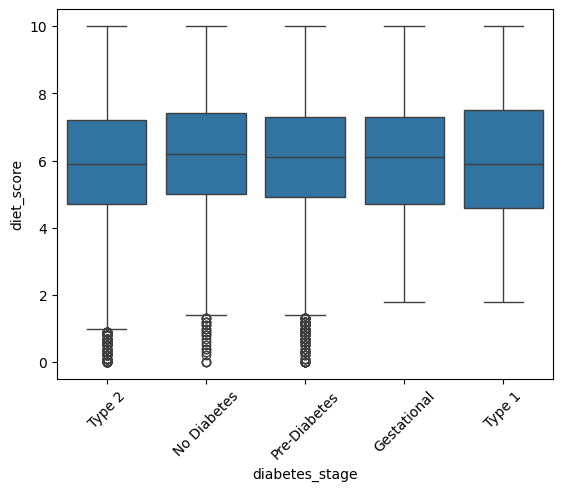

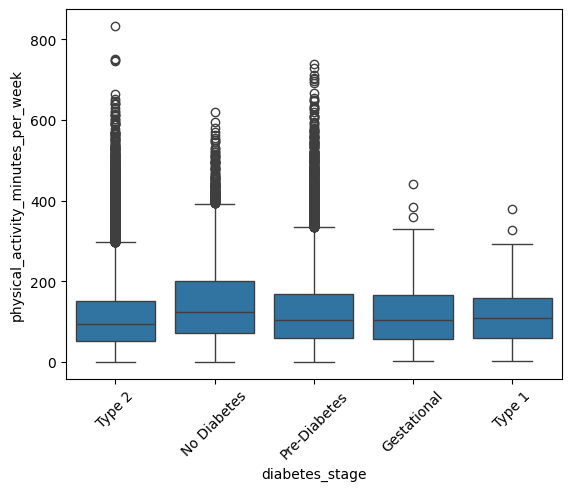

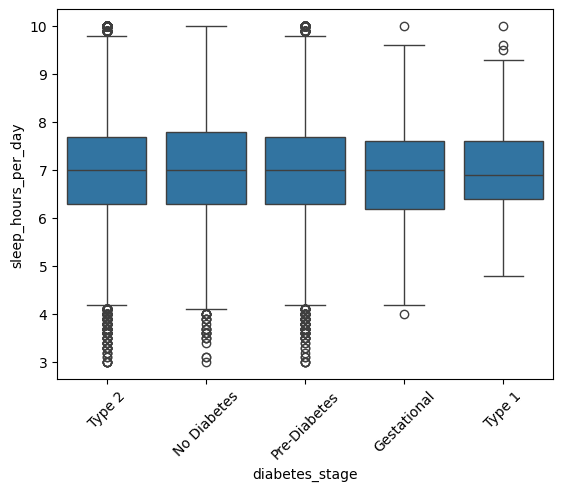

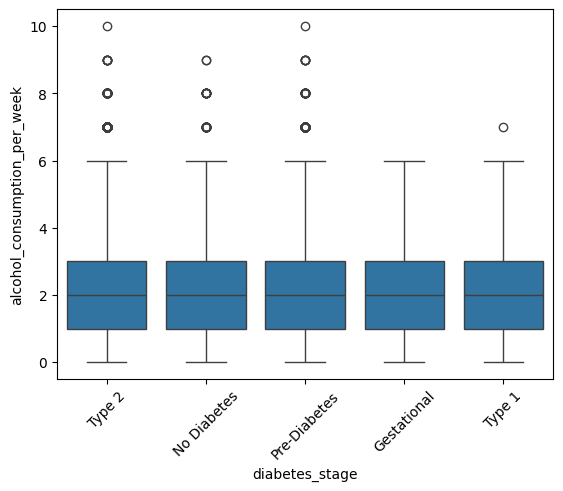

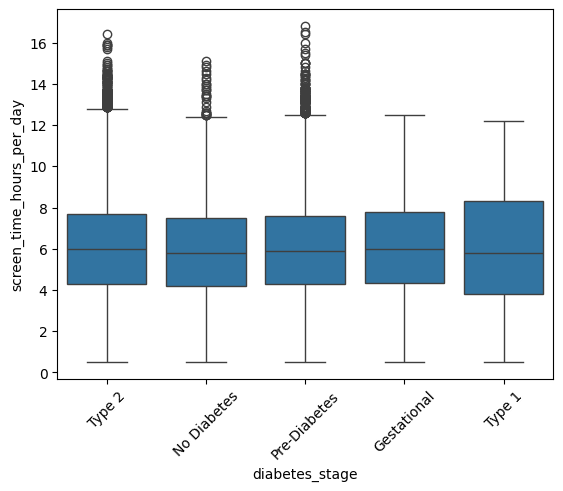

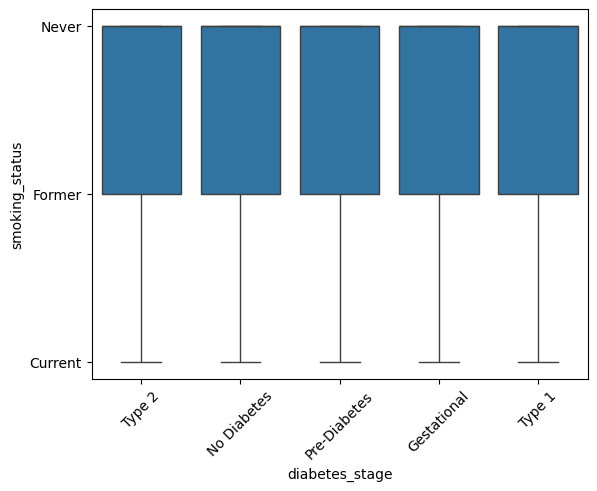

In [14]:
lifestyle = ['diet_score', 'physical_activity_minutes_per_week', 
             'sleep_hours_per_day', 'alcohol_consumption_per_week',
             'screen_time_hours_per_day', 'smoking_status']

for feat in lifestyle:
    sns.boxplot(data=df, x='diabetes_stage', y=feat)
    plt.xticks(rotation=45)
    plt.show()

In [15]:
for col in ['gender', 'ethnicity', 'education_level', 'income_level', 
            'smoking_status', 'employment_status']:
    print(df.groupby(col)['diabetes_stage'].value_counts(normalize=True))

gender  diabetes_stage
Female  Type 2            0.594664
        Pre-Diabetes      0.319154
        No Diabetes       0.079615
        Gestational       0.005463
        Type 1            0.001105
Male    Type 2            0.599978
        Pre-Diabetes      0.319737
        No Diabetes       0.079036
        Type 1            0.001248
Other   Type 2            0.623727
        Pre-Diabetes      0.285132
        No Diabetes       0.088595
        Type 1            0.002546
Name: proportion, dtype: float64
ethnicity  diabetes_stage
Asian      Type 2            0.599115
           Pre-Diabetes      0.320552
           No Diabetes       0.076863
           Gestational       0.002689
           Type 1            0.000781
Black      Type 2            0.599292
           Pre-Diabetes      0.315242
           No Diabetes       0.081753
           Gestational       0.002514
           Type 1            0.001200
Hispanic   Type 2            0.592164
           Pre-Diabetes      0.324110
       

#### histograms

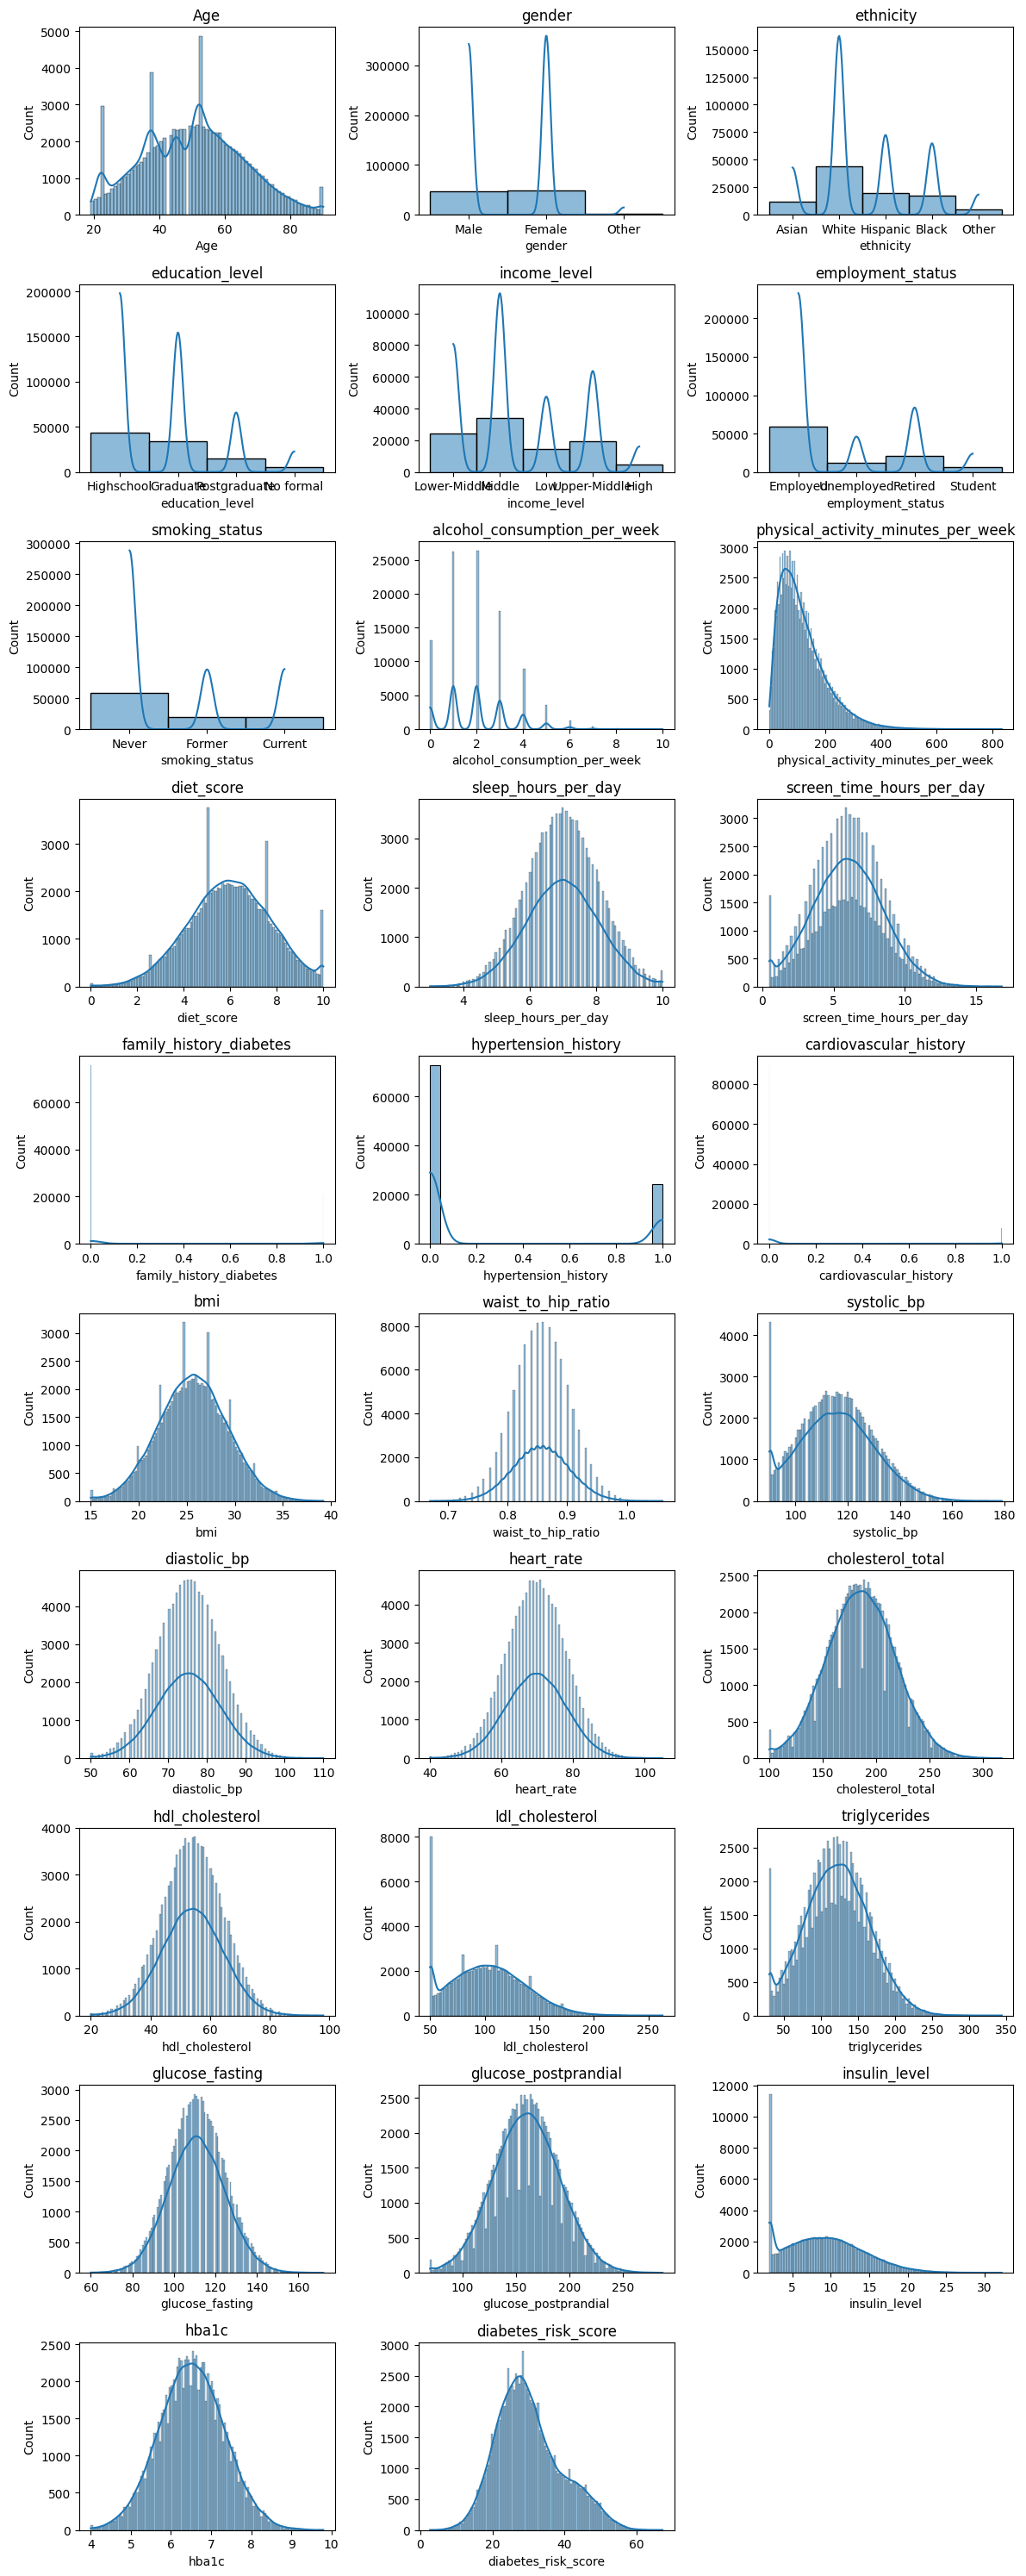

In [16]:
df_split = df.copy()
Inputs = df.drop(columns=['diabetes_stage','diagnosed_diabetes'])
outputs = df['diabetes_stage']

plt.figure(figsize=(12, 30))
for i, col in enumerate(Inputs):
    plt.subplot(10, 3, i+1)
    sns.histplot(df_split[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

#### due to the following 3 making use of binary answers, we make custom histograms for them

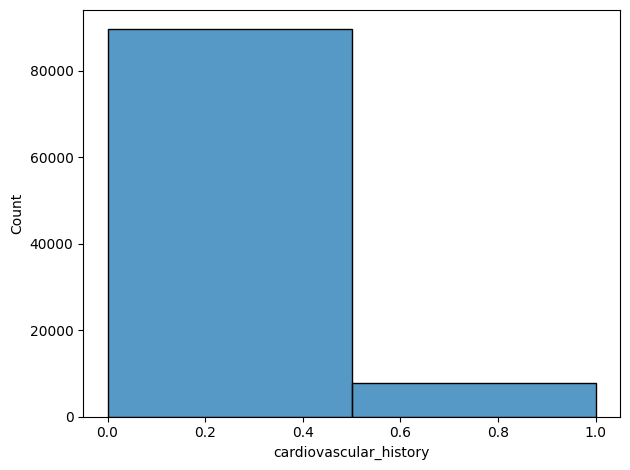

In [17]:
sns.histplot(df_split['cardiovascular_history'], bins=2, kde=False)
plt.tight_layout()
plt.show()

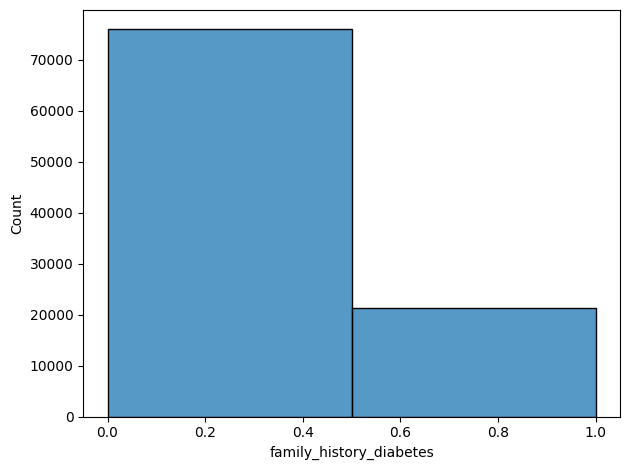

In [18]:
sns.histplot(df_split['family_history_diabetes'], bins=2, kde=False)
plt.tight_layout()
plt.show()

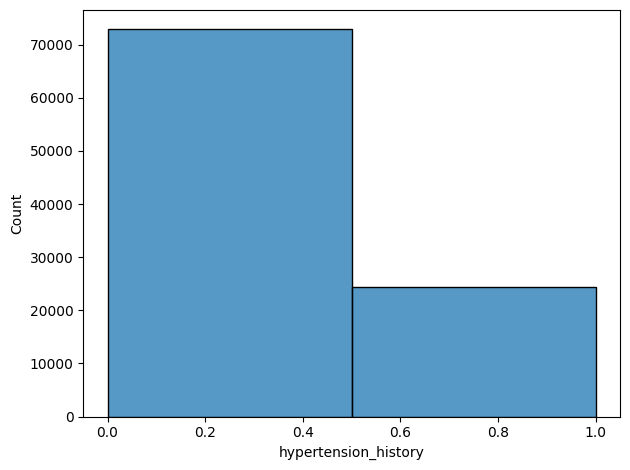

In [19]:
sns.histplot(df_split['hypertension_history'], bins=2, kde=False)
plt.tight_layout()
plt.show()